# Baseline CNN for Guitar Type Classification

This notebook implements a **simple baseline Convolutional Neural Network (CNN)**
built from scratch using PyTorch for multi-class image classification.

**Task:** Classify guitar images into 3 categories:
- Acoustic Guitar
- Electric Guitar
- Bass Guitar

**Purpose:** This model serves as the **benchmark baseline**. It is intentionally
kept simple so that future, more advanced models can be compared against it.

## 1. Imports and Setup

In [1]:
import os
import copy
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


## 2. Hyperparameters and Configuration

All key hyperparameters are defined here for easy modification.

In [2]:
#  Paths 
DATA_DIR = "dataset"                # Root directory of the ImageFolder dataset
SAVE_PATH = "best_baseline_model.pth"  # Path to save the best model weights

#  Image settings 
IMAGE_SIZE = 224                    # Resize all images to 224×224

#  Training settings 
BATCH_SIZE = 32                     # Mini-batch size
NUM_EPOCHS = 20                     # Number of training epochs
LEARNING_RATE = 0.001               # Adam optimizer learning rate
NUM_CLASSES = 3                     # acoustic, electric, bass

# Dataset split ratios 
TRAIN_RATIO = 0.70                  # 70% training
VAL_RATIO = 0.15                    # 15% validation
TEST_RATIO = 0.15                   # 15% testing

#  Reproducibility 
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## 3. Device Configuration

Automatically detect and use GPU if available (e.g., A100 on Google Colab).

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 4. Data Loading and Preprocessing

We apply **basic preprocessing only** (no data augmentation) since this is the
baseline model:
- Resize to 224×224
- Convert to Tensor
- Normalize using ImageNet mean and standard deviation

The dataset is split into **Train (70%)**, **Validation (15%)**, and **Test (15%)**.

In [4]:
def get_transforms():
    """
    Define basic image transforms.
    Only resize, convert to tensor, and normalize — no augmentation.
    """
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std  = [0.229, 0.224, 0.225]

    transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),   # Resize to 224×224
        transforms.ToTensor(),                          # Convert PIL image to tensor
        transforms.Normalize(mean=imagenet_mean,        # Normalize with ImageNet stats
                             std=imagenet_std),
    ])
    return transform


def load_and_split_data(transform):
    """
    Load the dataset using ImageFolder and split into train/val/test sets.

    Returns:
        train_loader, val_loader, test_loader, class_names
    """
    # Verify dataset directory exists
    if not os.path.isdir(DATA_DIR):
        raise FileNotFoundError(
            f"[ERROR] '{DATA_DIR}' directory not found. "
            "Please ensure the dataset is in the correct location."
        )

    # Load full dataset with ImageFolder
    full_dataset = ImageFolder(root=DATA_DIR, transform=transform)
    class_names  = full_dataset.classes
    n_total      = len(full_dataset)

    # Calculate split sizes
    n_train = int(n_total * TRAIN_RATIO)
    n_val   = int(n_total * VAL_RATIO)
    n_test  = n_total - n_train - n_val  # Remainder goes to test

    # Perform the split with a fixed seed for reproducibility
    train_dataset, val_dataset, test_dataset = random_split(
        full_dataset,
        [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(RANDOM_SEED)
    )

    # Create DataLoaders
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE,
        shuffle=True, num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=2, pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=2, pin_memory=True
    )

    # Print dataset summary
    print(f"[INFO] Classes: {class_names}")
    print(f"[INFO] Total images : {n_total}")
    print(f"[INFO]   Train      : {n_train} ({TRAIN_RATIO*100:.0f}%)")
    print(f"[INFO]   Validation : {n_val} ({VAL_RATIO*100:.0f}%)")
    print(f"[INFO]   Test       : {n_test} ({TEST_RATIO*100:.0f}%)")

    return train_loader, val_loader, test_loader, class_names


# Load data
transform = get_transforms()
train_loader, val_loader, test_loader, class_names = load_and_split_data(transform)

[INFO] Classes: ['acoustic', 'bass', 'electric']
[INFO] Total images : 4435
[INFO]   Train      : 3104 (70%)
[INFO]   Validation : 665 (15%)
[INFO]   Test       : 666 (15%)


## 5. Baseline CNN Architecture

A simple CNN with:
- **3 Convolutional layers** (increasing filters: 32 → 64 → 128)
- **ReLU** activation after each convolution
- **MaxPooling** (2×2) after each convolution to downsample
- **Flatten** layer to convert feature maps to a 1D vector
- **2 Fully connected layers** (512 → 3)
- **Output layer** with 3 neurons (one per class)

This architecture is intentionally kept simple as a baseline benchmark.

In [5]:
class BaselineCNN(nn.Module):
    """
    Simple baseline CNN for guitar type classification.

    Architecture:
        Input (3 × 224 × 224)
        → Conv1 (32 filters) → ReLU → MaxPool
        → Conv2 (64 filters) → ReLU → MaxPool
        → Conv3 (128 filters) → ReLU → MaxPool
        → Flatten
        → FC1 (512) → ReLU
        → FC2 (3)  ← output logits
    """

    def __init__(self, num_classes=NUM_CLASSES):
        super(BaselineCNN, self).__init__()

        #  Feature extractor 
        # Conv Layer 1: 3 input channels → 32 feature maps
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Output: 32 × 112 × 112

        # Conv Layer 2: 32 → 64 feature maps
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Output: 64 × 56 × 56

        # Conv Layer 3: 64 → 128 feature maps
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Output: 128 × 28 × 28

        #  Classifier 
        self.flatten = nn.Flatten()
        self.fc1  = nn.Linear(128 * 28 * 28, 512)   # Flatten → 512
        self.relu4 = nn.ReLU()
        self.fc2  = nn.Linear(512, num_classes)       # 512 → num_classes

    def forward(self, x):
        # Feature extraction
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))

        # Classification
        x = self.flatten(x)
        x = self.relu4(self.fc1(x))
        x = self.fc2(x)
        return x


# Instantiate model and move to device
model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
print(model)

# Print total number of trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n[INFO] Total trainable parameters: {total_params:,}")

BaselineCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=100352, out_features=512, bias=True)
  (relu4): ReLU()
  (fc2): Linear(in_features=512, out_features=3, bias=True)
)

[INFO] Total trainable parameters: 51,475,523


## 6. Loss Function and Optimizer

- **CrossEntropyLoss**: Standard loss for multi-class classification.
- **Adam optimizer**: Adaptive learning rate optimizer with lr = 0.001.

In [6]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

## 7. Training and Validation Functions

Modular functions for training one epoch and evaluating on a dataset.

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Train the model for one epoch.

    Args:
        model: The CNN model.
        loader: DataLoader for training data.
        criterion: Loss function.
        optimizer: Optimizer.
        device: Device to run on (CPU/GPU).

    Returns:
        avg_loss: Average training loss for the epoch.
        accuracy: Training accuracy for the epoch.
    """
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        # Move data to device
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Evaluate the model on a given dataset.

    Args:
        model: The CNN model.
        loader: DataLoader for evaluation data.
        criterion: Loss function.
        device: Device to run on (CPU/GPU).

    Returns:
        avg_loss: Average loss.
        accuracy: Accuracy.
        all_preds: List of all predictions.
        all_labels: List of all true labels.
    """
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass only
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Track statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy, all_preds, all_labels

## 8. Training Loop

Train for 20 epochs, tracking loss and accuracy for both training and validation.
The best model (by validation accuracy) is saved automatically.

In [8]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device,
                num_epochs=NUM_EPOCHS):
    """
    Full training loop with validation and best-model checkpointing.

    Returns:
        model: Model loaded with best weights.
        history: Dictionary of training/validation loss and accuracy per epoch.
    """
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [],   "val_acc": []
    }
    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    
    print(f"  Training Baseline CNN for {num_epochs} epochs")
    

    for epoch in range(1, num_epochs + 1):
        t_start = time.time()

        # Train for one epoch
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        # Validate
        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, criterion, device
        )

        # Record history
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        elapsed = time.time() - t_start

        # Print epoch results
        print(
            f"Epoch [{epoch:>2}/{num_epochs}]  "
            f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}%  |  "
            f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc*100:.2f}%  |  "
            f"Time: {elapsed:.1f}s"
        )

        # Save best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, SAVE_PATH)
            print(f"  → Best model saved (val_acc: {best_val_acc*100:.2f}%)")

    # Load the best weights
    model.load_state_dict(best_weights)
    
    print(f"  Training complete. Best validation accuracy: {best_val_acc*100:.2f}%")

    return model, history


# Run training
model, history = train_model(
    model, train_loader, val_loader, criterion, optimizer, device
)

  Training Baseline CNN for 20 epochs
Epoch [ 1/20]  Train Loss: 1.2501  Train Acc: 45.33%  |  Val Loss: 0.9639  Val Acc: 54.44%  |  Time: 6.9s
  → Best model saved (val_acc: 54.44%)
Epoch [ 2/20]  Train Loss: 0.8950  Train Acc: 56.57%  |  Val Loss: 0.8498  Val Acc: 59.55%  |  Time: 5.7s
  → Best model saved (val_acc: 59.55%)
Epoch [ 3/20]  Train Loss: 0.7543  Train Acc: 65.72%  |  Val Loss: 0.8584  Val Acc: 60.75%  |  Time: 6.2s
  → Best model saved (val_acc: 60.75%)
Epoch [ 4/20]  Train Loss: 0.5652  Train Acc: 76.90%  |  Val Loss: 0.8061  Val Acc: 64.81%  |  Time: 5.8s
  → Best model saved (val_acc: 64.81%)
Epoch [ 5/20]  Train Loss: 0.3719  Train Acc: 85.86%  |  Val Loss: 0.9753  Val Acc: 67.37%  |  Time: 6.0s
  → Best model saved (val_acc: 67.37%)
Epoch [ 6/20]  Train Loss: 0.2106  Train Acc: 93.11%  |  Val Loss: 1.3052  Val Acc: 63.46%  |  Time: 5.7s
Epoch [ 7/20]  Train Loss: 0.1132  Train Acc: 96.71%  |  Val Loss: 1.3783  Val Acc: 67.67%  |  Time: 5.9s
  → Best model saved (val

## 9. Training Curves

Plot the training and validation loss/accuracy over epochs to visualize
the model's learning behaviour.

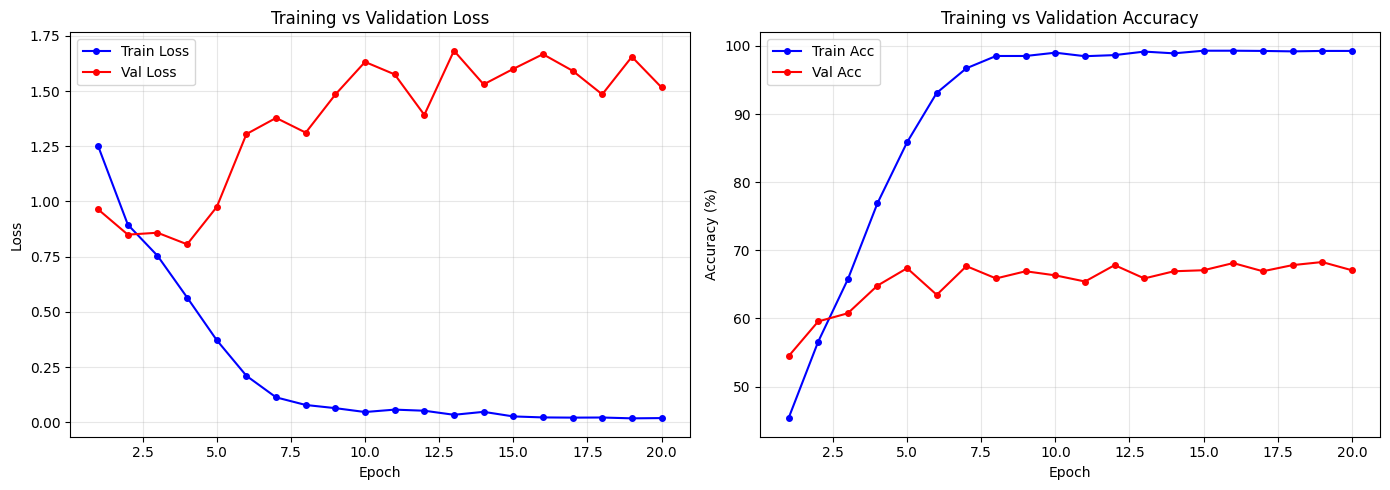

In [9]:
def plot_training_curves(history):
    """Plot training and validation loss/accuracy curves."""
    epochs_range = range(1, len(history["train_loss"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    #  Loss curve 
    ax1.plot(epochs_range, history["train_loss"], "b-o", label="Train Loss", markersize=4)
    ax1.plot(epochs_range, history["val_loss"],   "r-o", label="Val Loss", markersize=4)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Training vs Validation Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    #  Accuracy curve 
    ax2.plot(epochs_range, [a * 100 for a in history["train_acc"]], "b-o",
             label="Train Acc", markersize=4)
    ax2.plot(epochs_range, [a * 100 for a in history["val_acc"]],   "r-o",
             label="Val Acc", markersize=4)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_title("Training vs Validation Accuracy")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training_curves(history)

## 10. Test Set Evaluation

Evaluate the best model on the held-out **test set** to get the final,
unbiased performance estimate.

In [10]:
def evaluate_on_test(model, test_loader, criterion, device, class_names):
    """
    Evaluate the model on the test set and print detailed results.

    Returns:
        test_acc: Final test accuracy.
        all_preds: Predictions on test set.
        all_labels: True labels of test set.
    """
    test_loss, test_acc, all_preds, all_labels = evaluate(
        model, test_loader, criterion, device
    )

    
    print(f"  FINAL TEST RESULTS")
    
    print(f"  Test Loss     : {test_loss:.4f}")
    print(f"  Test Accuracy : {test_acc*100:.2f}%")
    

    # Detailed classification report
    print("Classification Report:")
    print("-" * 60)
    print(classification_report(
        all_labels, all_preds,
        target_names=class_names, digits=4
    ))

    return test_acc, all_preds, all_labels


test_acc, all_preds, all_labels = evaluate_on_test(
    model, test_loader, criterion, device, class_names
)

  FINAL TEST RESULTS
  Test Loss     : 1.6029
  Test Accuracy : 66.52%
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

    acoustic     0.7212    0.7342    0.7277       222
        bass     0.6889    0.5794    0.6294       214
    electric     0.6000    0.6783    0.6367       230

    accuracy                         0.6652       666
   macro avg     0.6700    0.6640    0.6646       666
weighted avg     0.6690    0.6652    0.6647       666



## 11. Confusion Matrix

Visualize the confusion matrix to see where the model makes errors.

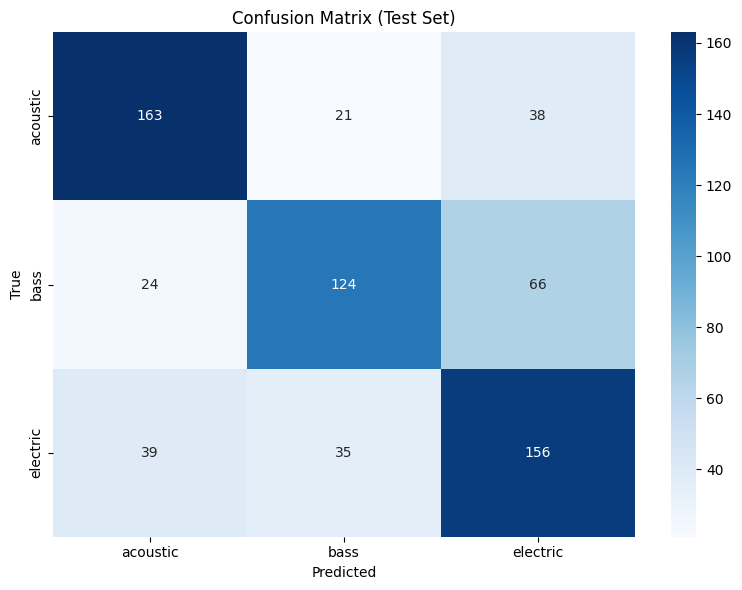

In [11]:
def plot_confusion_matrix(all_labels, all_preds, class_names):
    """Plot a heatmap confusion matrix."""
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix (Test Set)")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(all_labels, all_preds, class_names)

## 12. Sample Predictions

Visualize a few sample images from the test set along with their
predicted and true labels.

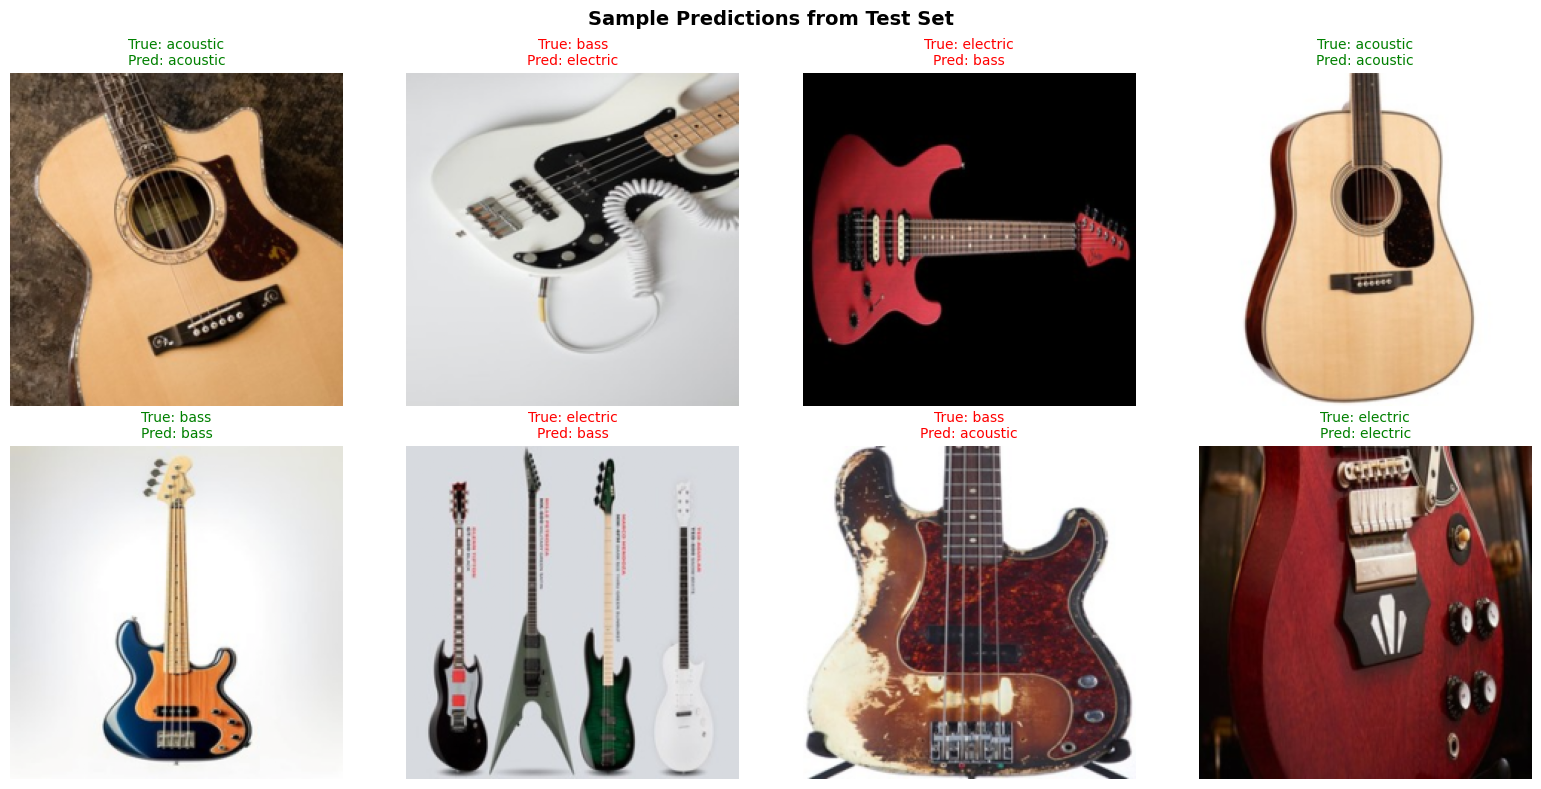

In [12]:
def show_sample_predictions(model, test_loader, class_names, device, num_samples=8):
    """Display sample predictions from the test set."""
    # Get one batch
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    # De-normalize for display
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    num_samples = min(num_samples, len(images))
    fig, axes = plt.subplots(2, num_samples // 2, figsize=(16, 8))
    axes = axes.flatten()

    for i in range(num_samples):
        img = images[i].cpu() * std + mean  # De-normalize
        img = img.clamp(0, 1)               # Clamp to valid range
        img = img.permute(1, 2, 0).numpy()  # CHW → HWC

        true_label = class_names[labels[i].item()]
        pred_label = class_names[preds[i].item()]
        color = "green" if true_label == pred_label else "red"

        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
        axes[i].axis("off")

    plt.suptitle("Sample Predictions from Test Set", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


show_sample_predictions(model, test_loader, class_names, device)

## Summary

This baseline CNN provides a simple benchmark for the guitar classification task.
Key characteristics:
- **Simple architecture**: 3 conv layers + 2 FC layers, no fancy techniques
- **No data augmentation**: Only basic resize + normalize
- **No regularization**: No dropout, batch normalization, or weight decay
- **No learning rate scheduling**: Fixed learning rate throughout training

Future improvements to compare against this baseline:
- Data augmentation (flips, rotations, colour jitter)
- Deeper architectures or pre-trained models (transfer learning)
- Regularisation techniques (dropout, batch norm, weight decay)
- Learning rate scheduling
- Hyperparameter tuning